# Pipeline analisi mutazioni — utilizzo di utils.py
Basta cambiare `PATH` e i parametri, poi eseguire le celle in ordine.

##  INIT

In [2]:

from utils import (generate_matrices, calculate_statistics,
                    plot_volcanos, build_all_networks,
                    calculate_metrics, compare_networks)

import os
import pandas as pd

## Funzione di stratificazione

In [3]:

def stratify_cohort(input_dir, output_dir, master_filename, filter_type, **kwargs):
    print(f"\n{'='*50}")
    print(f"=== STRATIFICAZIONE: {os.path.basename(input_dir)} -> {os.path.basename(output_dir)} ===")
    
    master_path = os.path.join(input_dir, master_filename)
    if not os.path.exists(master_path):
        print(f"Errore: File master non trovato -> {master_path}")
        return None, None
        
    group_a_name = "Matched"
    group_b_name = "Unmatched"
        
    master_df = pd.read_csv(master_path, sep='\t', low_memory=False)
    # Assicuriamoci di togliere spazi anche dagli ID
    all_ids = set(master_df['Sample_Id'].astype(str).str.strip().unique())
    
    group_a_ids = set()
    
    # --- LOGICA DEI FILTRI ---
    if filter_type == 'mutation':
        gene = kwargs.get('gene')
        mut_files = [f for f in os.listdir(input_dir) if 'mutations' in f.lower()]
        
        if not mut_files:
             print(f"Errore: Nessun file mutazioni trovato in {input_dir}")
             return None, None
             
        mut_file_path = os.path.join(input_dir, mut_files[0])
        mut_df = pd.read_csv(mut_file_path, sep='\t', low_memory=False)
        
        if 'Hugo_Symbol' not in mut_df.columns:
            print("Errore: Colonna 'Hugo_Symbol' mancante nel file mutazioni.")
            return None, None
            
        # 1. Standardizza il nome del gene (maiuscolo e senza spazi)
        gene_target = str(gene).strip().upper()
        
        # 2. Applica la stessa standardizzazione alla colonna Hugo_Symbol
        mask = mut_df['Hugo_Symbol'].astype(str).str.strip().str.upper() == gene_target
        
        # 3. Estrai gli ID
        mutated_samples_raw = mut_df[mask]['Sample_Id'].astype(str).str.strip().unique()
        print(f"[Debug] Trovati {len(mutated_samples_raw)} pazienti unici con mutazione {gene_target} nel file mutazioni.")
        
        group_a_ids = set(mutated_samples_raw).intersection(all_ids)
        print(f"[Debug] Di questi, {len(group_a_ids)} sono presenti nel master file clinico.")
        
    elif filter_type == 'clinical':
        column = kwargs.get('column')
        value = kwargs.get('value')
        
        if column not in master_df.columns:
            print(f"Errore: Colonna clinica '{column}' non trovata nel master.")
            return None, None
            
        # Filtro feature clinica (anche qui cast a stringa per sicurezza)
        mask = master_df[column].astype(str).str.strip() == str(value).strip()
        matched_samples = master_df[mask]['Sample_Id'].astype(str).str.strip().unique()
        group_a_ids = set(matched_samples)
        
    else:
        print("Errore: filter_type deve essere 'mutation' o 'clinical'.")
        return None, None
        
    # --- CALCOLO DEI GRUPPI ---
    group_b_ids = all_ids - group_a_ids
    
    print(f"Totale pazienti nella coorte originale: {len(all_ids)}")
    print(f"  -> Pazienti assegnati a {group_a_name}: {len(group_a_ids)}")
    print(f"  -> Pazienti assegnati a {group_b_name}: {len(group_b_ids)}")
    
    if len(group_a_ids) == 0 or len(group_b_ids) == 0:
        print("! Attenzione: Uno dei due gruppi è vuoto. Controlla il nome del gene/feature.")

    # --- CREAZIONE CARTELLE ---
    path_a = os.path.join(output_dir, group_a_name)
    path_b = os.path.join(output_dir, group_b_name)
    os.makedirs(path_a, exist_ok=True)
    os.makedirs(path_b, exist_ok=True)

    # --- SMISTAMENTO DI TUTTI I FILE ---
    print("\nSmistamento dei file in corso...")
    
    for filename in os.listdir(input_dir):
        file_path = os.path.join(input_dir, filename)
        
        if not os.path.isfile(file_path):
            continue
            
        df = pd.read_csv(file_path, sep='\t', low_memory=False)
        
        if 'Sample_Id' in df.columns:
            # Pulisco gli ID prima del match
            df['Sample_Id_clean'] = df['Sample_Id'].astype(str).str.strip()
            
            df_a = df[df['Sample_Id_clean'].isin(group_a_ids)].drop(columns=['Sample_Id_clean'])
            df_b = df[df['Sample_Id_clean'].isin(group_b_ids)].drop(columns=['Sample_Id_clean'])
            
            df_a.to_csv(os.path.join(path_a, filename), sep='\t', index=False)
            df_b.to_csv(os.path.join(path_b, filename), sep='\t', index=False)
            print(f"[Righe]   {filename}: {len(df_a)} in {group_a_name} | {len(df_b)} in {group_b_name}")
            
        else:
            # Per i file CNA pulisco i nomi delle colonne
            clean_cols = {c: str(c).strip() for c in df.columns}
            df_renamed = df.rename(columns=clean_cols)
            col_ids = set(df_renamed.columns).intersection(all_ids)
            
            if len(col_ids) > 0:
                base_cols = [c for c in df_renamed.columns if c not in all_ids]
                
                cols_a = base_cols + [c for c in df_renamed.columns if c in group_a_ids]
                cols_b = base_cols + [c for c in df_renamed.columns if c in group_b_ids]
                
                # Ripristina i nomi originali in output per non scombinare la pipeline
                reverse_map = {v: k for k, v in clean_cols.items()}
                
                df_a = df_renamed[cols_a].rename(columns=reverse_map)
                df_b = df_renamed[cols_b].rename(columns=reverse_map)
                
                df_a.to_csv(os.path.join(path_a, filename), sep='\t', index=False)
                df_b.to_csv(os.path.join(path_b, filename), sep='\t', index=False)
                print(f"[Colonne] {filename}: {len(cols_a)-len(base_cols)} campioni in {group_a_name} | {len(cols_b)-len(base_cols)} campioni in {group_b_name}")
            else:
                print(f"[Ignorato] {filename}: Non contiene 'Sample_Id' né come righe né come colonne.")

    print(f"=== FATTO ===")
    return path_a, path_b

## Prova con TP53

In [4]:
COOCC_PARAMS = {"p_val": 0.05, "log2or": 1.0, "min_cooc": 3}
ME_PARAMS    = {"p_val": 0.01, "log2or": -1.0}


=== STRATIFICAZIONE: kras_pancreas -> kras_tp53_pancreas ===
[Debug] Trovati 660 pazienti unici con mutazione TP53 nel file mutazioni.
[Debug] Di questi, 660 sono presenti nel master file clinico.
Totale pazienti nella coorte originale: 807
  -> Pazienti assegnati a Matched: 660
  -> Pazienti assegnati a Unmatched: 147

Smistamento dei file in corso...
[Colonne] F_data_cna.txt: 660 campioni in Matched | 147 campioni in Unmatched
[Righe]   F_data_mutations.txt: 3140 in Matched | 715 in Unmatched
[Righe]   F_data_SV.csv: 117 in Matched | 30 in Unmatched
[Righe]   KRAS_F_pancreas.csv: 660 in Matched | 147 in Unmatched
=== FATTO ===

🧬 PREPARAZIONE DATI MUTAZIONI (SNV): MATCHED

📊 --- STATISTICHE RETE FINALE (SNV) ---
  • Dimensioni: 660 Campioni x 372 Geni unici
  • Densità matrice: 1.25%

  🔥 Top 5 Geni Driver (SNV):
    - TP53: 660 pazienti (100.0%)
    - KRAS: 660 pazienti (100.0%)
    - CDKN2A: 191 pazienti (28.9%)
    - SMAD4: 139 pazienti (21.1%)
    - ARID1A: 51 pazienti (7.7%)

✅

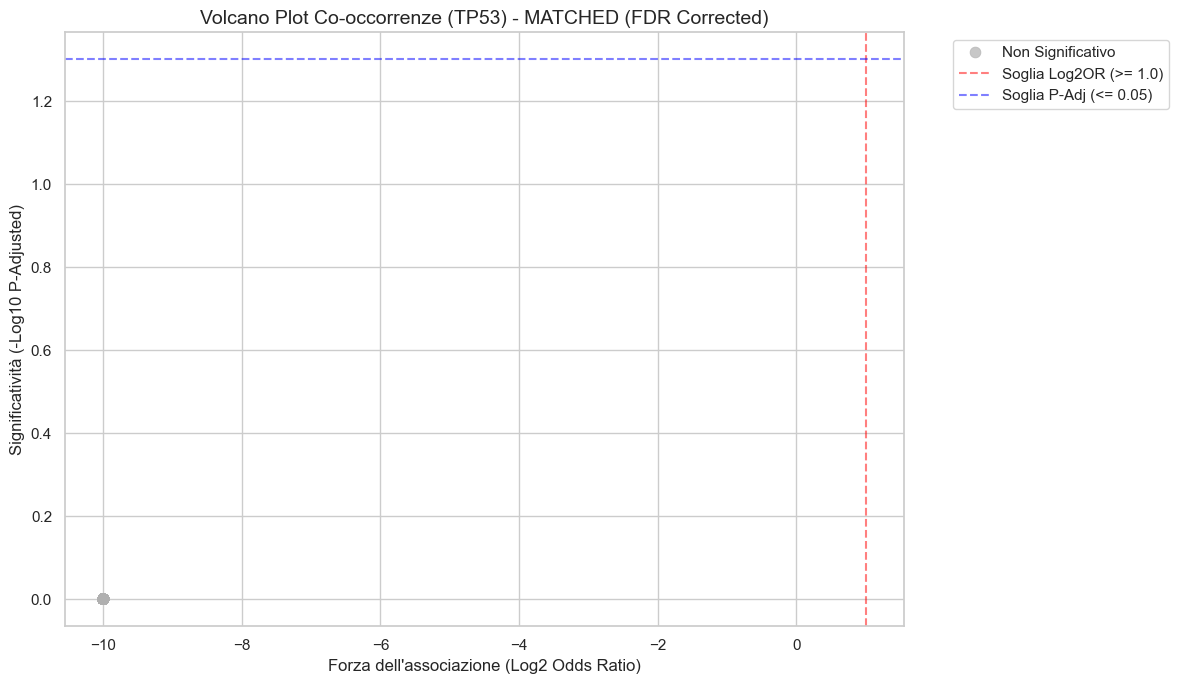

✅ Volcano Plot Co-occorrenze (P-Adj) salvato e visualizzato.



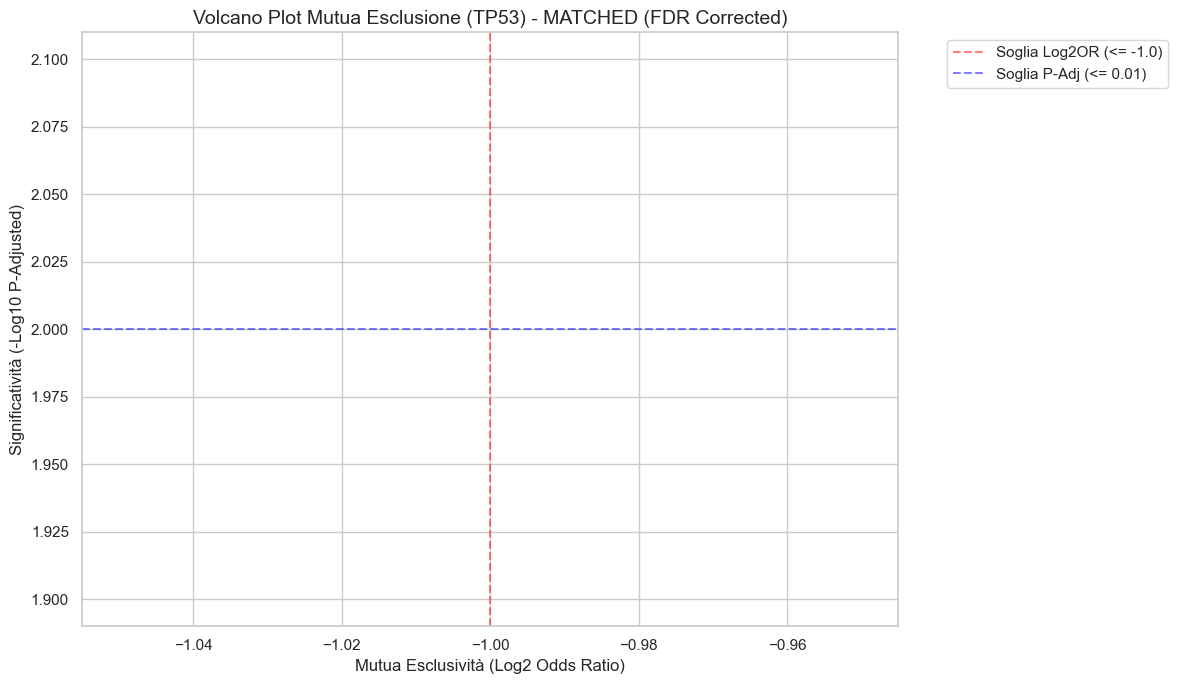

✅ Volcano Plot Mutua Esclusione (P-Adj) salvato e visualizzato.


--- 🌐 GENERAZIONE RETI 2D: MATCHED ---

📊 LEIDEN METRICS -> K: 5 | Modularity: 0.7264 | Silhouette: 0.9831
📁 File cluster salvato in: ./strat/kras_tp53_pancreas/matched\networks\Cluster_Genes_FULL_matched.tsv


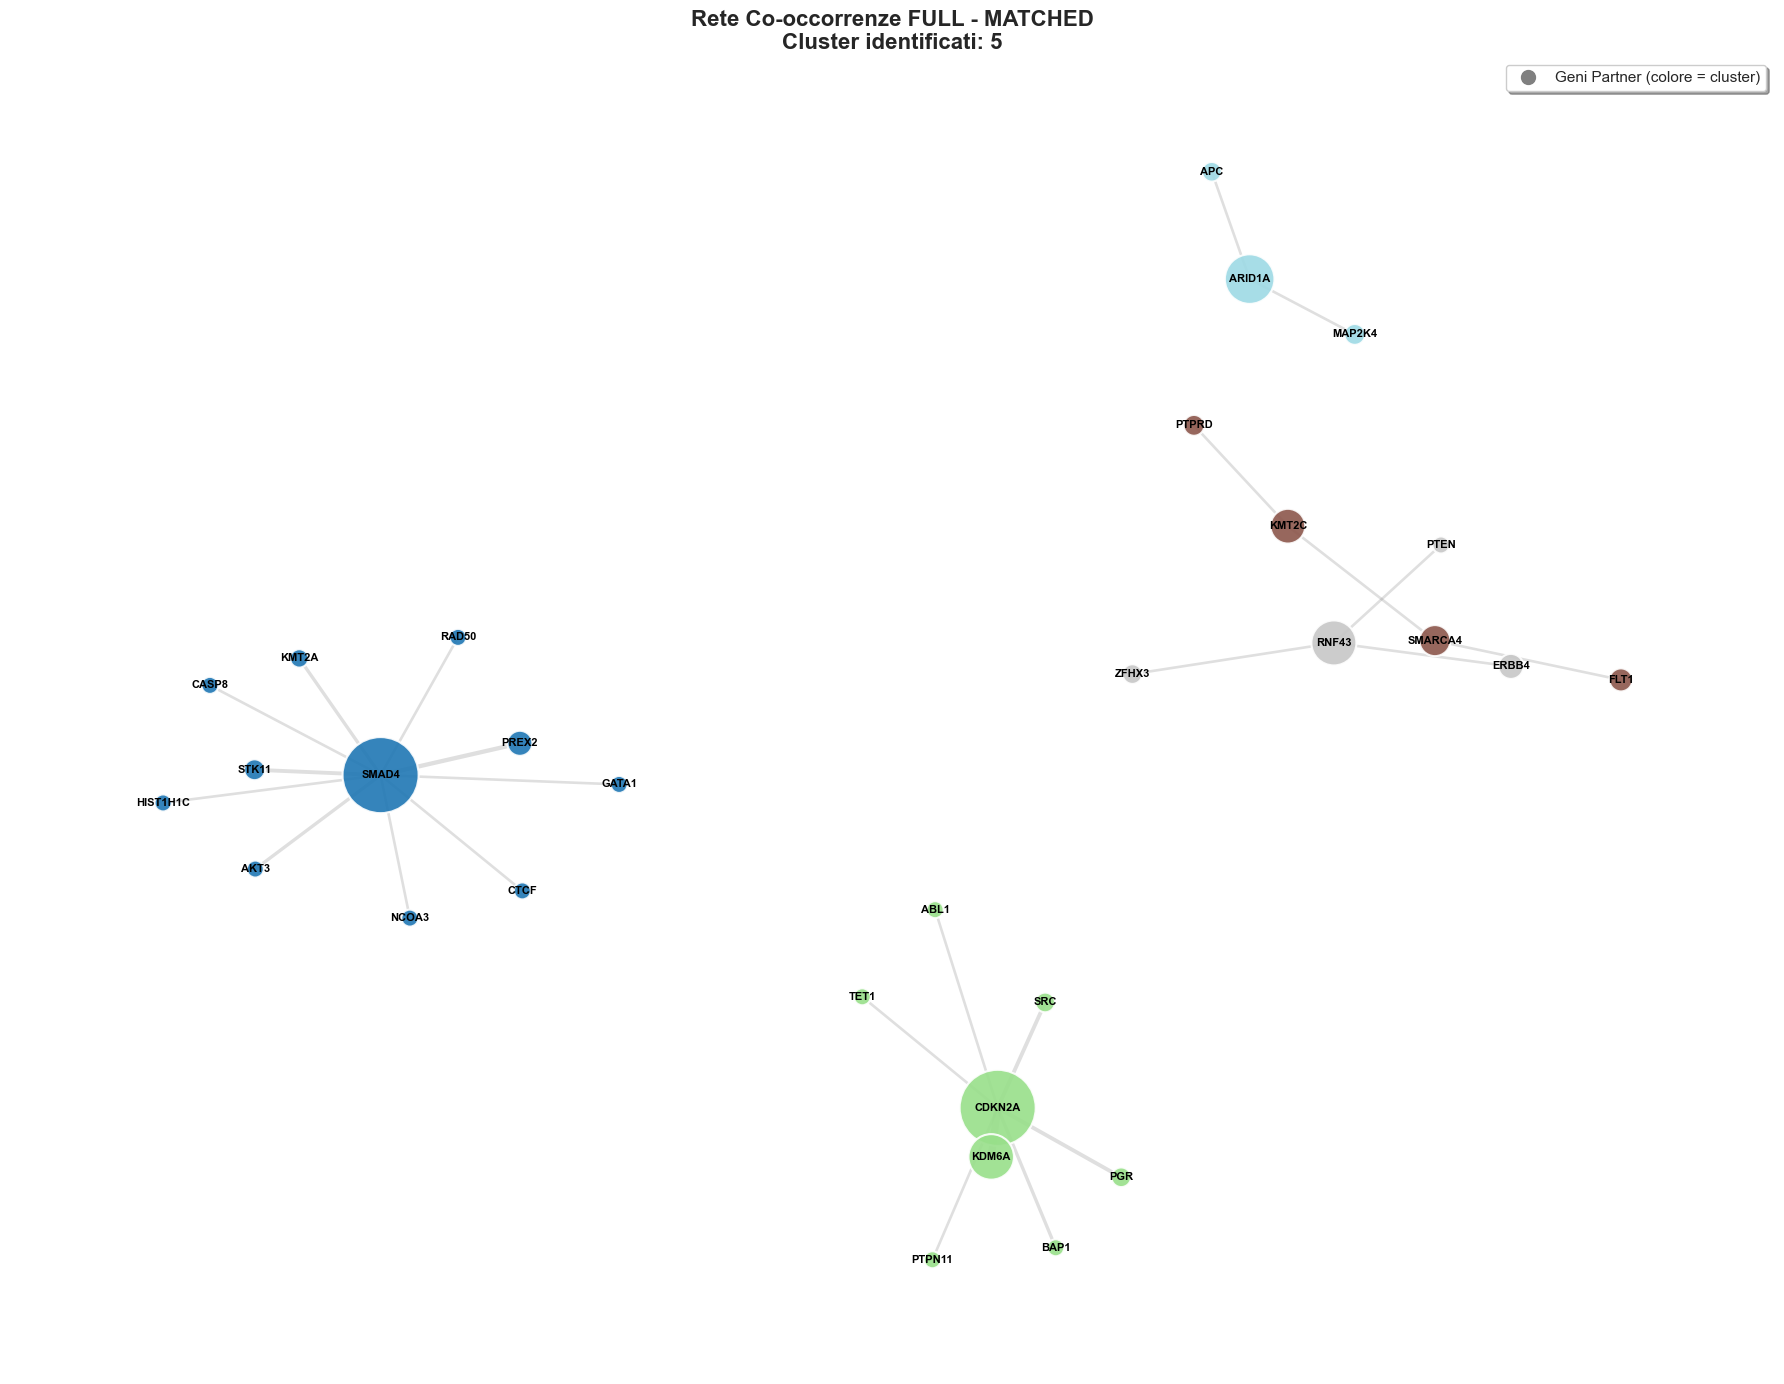

✅ Rete FULL per MATCHED salvata. Nodi: 30, Archi: 25
[!] TP53 non presente nella rete (non supera i filtri).

--- 📊 ESTRAZIONE METRICHE: MATCHED ---
[-] TP53 non presente, calcolo metriche annullato.


In [ ]:
# PATH        = "./strat/kras_tp53_pancreas/unmatched"
PATH        = "./strat/kras_tp53_pancreas/matched"
TARGET_GENE = "TP53"

INPUT_PATH = "./data_filtered/kras_pancreas"
OUTPUT_PATH = "./strat/kras_tp53_pancreas" 
FILE = 'KRAS_F_pancreas.csv'


stratify_cohort(input_dir = INPUT_PATH, output_dir = OUTPUT_PATH, master_filename = FILE, filter_type = 'mutation', gene = TARGET_GENE)

generate_matrices(PATH, TARGET_GENE)
calculate_statistics(PATH, TARGET_GENE, COOCC_PARAMS, ME_PARAMS)
plot_volcanos(PATH, TARGET_GENE, COOCC_PARAMS, ME_PARAMS)
build_all_networks(PATH, TARGET_GENE, COOCC_PARAMS)
calculate_metrics(PATH, TARGET_GENE, COOCC_PARAMS)




=== STRATIFICAZIONE: kras_pancreas -> kras_tp53_pancreas ===
[Debug] Trovati 660 pazienti unici con mutazione TP53 nel file mutazioni.
[Debug] Di questi, 660 sono presenti nel master file clinico.
Totale pazienti nella coorte originale: 807
  -> Pazienti assegnati a Matched: 660
  -> Pazienti assegnati a Unmatched: 147

Smistamento dei file in corso...
[Colonne] F_data_cna.txt: 660 campioni in Matched | 147 campioni in Unmatched
[Righe]   F_data_mutations.txt: 3140 in Matched | 715 in Unmatched
[Righe]   F_data_SV.csv: 117 in Matched | 30 in Unmatched
[Righe]   KRAS_F_pancreas.csv: 660 in Matched | 147 in Unmatched
=== FATTO ===

🧬 PREPARAZIONE DATI MUTAZIONI (SNV): UNMATCHED

📊 --- STATISTICHE RETE FINALE (SNV) ---
  • Dimensioni: 147 Campioni x 217 Geni unici
  • Densità matrice: 2.15%

  🔥 Top 5 Geni Driver (SNV):
    - KRAS: 147 pazienti (100.0%)
    - SMAD4: 46 pazienti (31.3%)
    - ATM: 23 pazienti (15.6%)
    - CDKN2A: 22 pazienti (15.0%)
    - ARID1A: 19 pazienti (12.9%)

✅ M

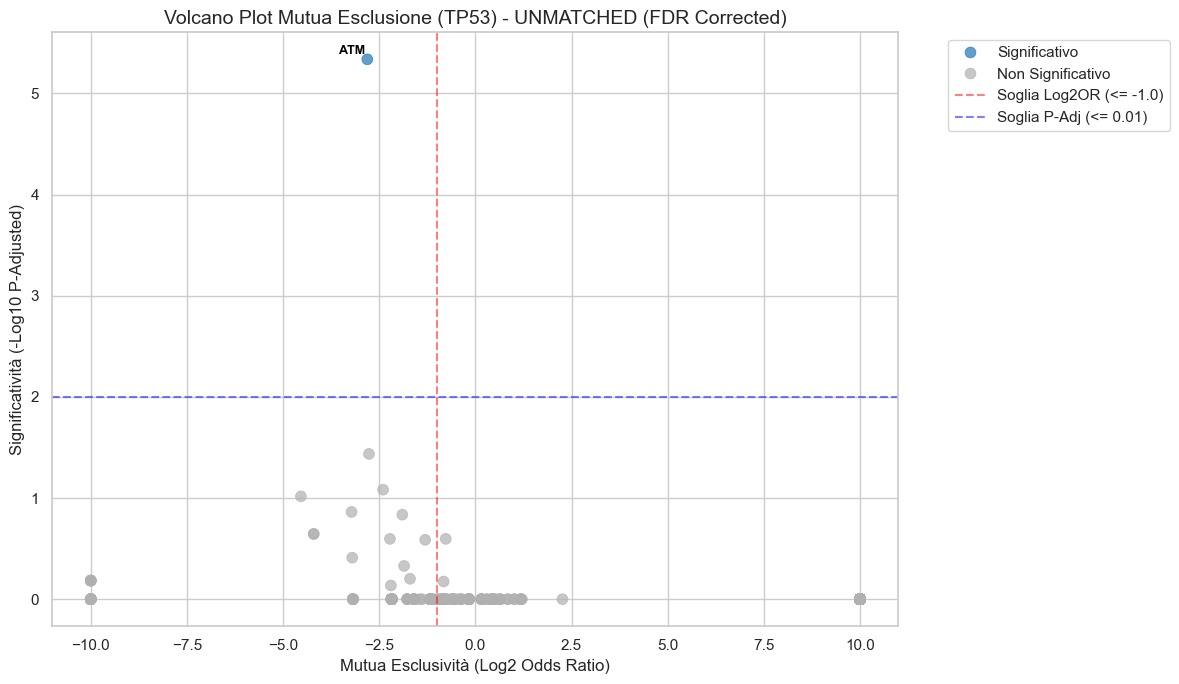

✅ Volcano Plot Mutua Esclusione (P-Adj) salvato e visualizzato.


--- 🌐 GENERAZIONE RETI 2D: UNMATCHED ---

📊 LEIDEN METRICS -> K: 4 | Modularity: 0.4401 | Silhouette: 0.4452
📁 File cluster salvato in: ./strat/kras_tp53_pancreas/unmatched\networks\Cluster_Genes_FULL_unmatched.tsv


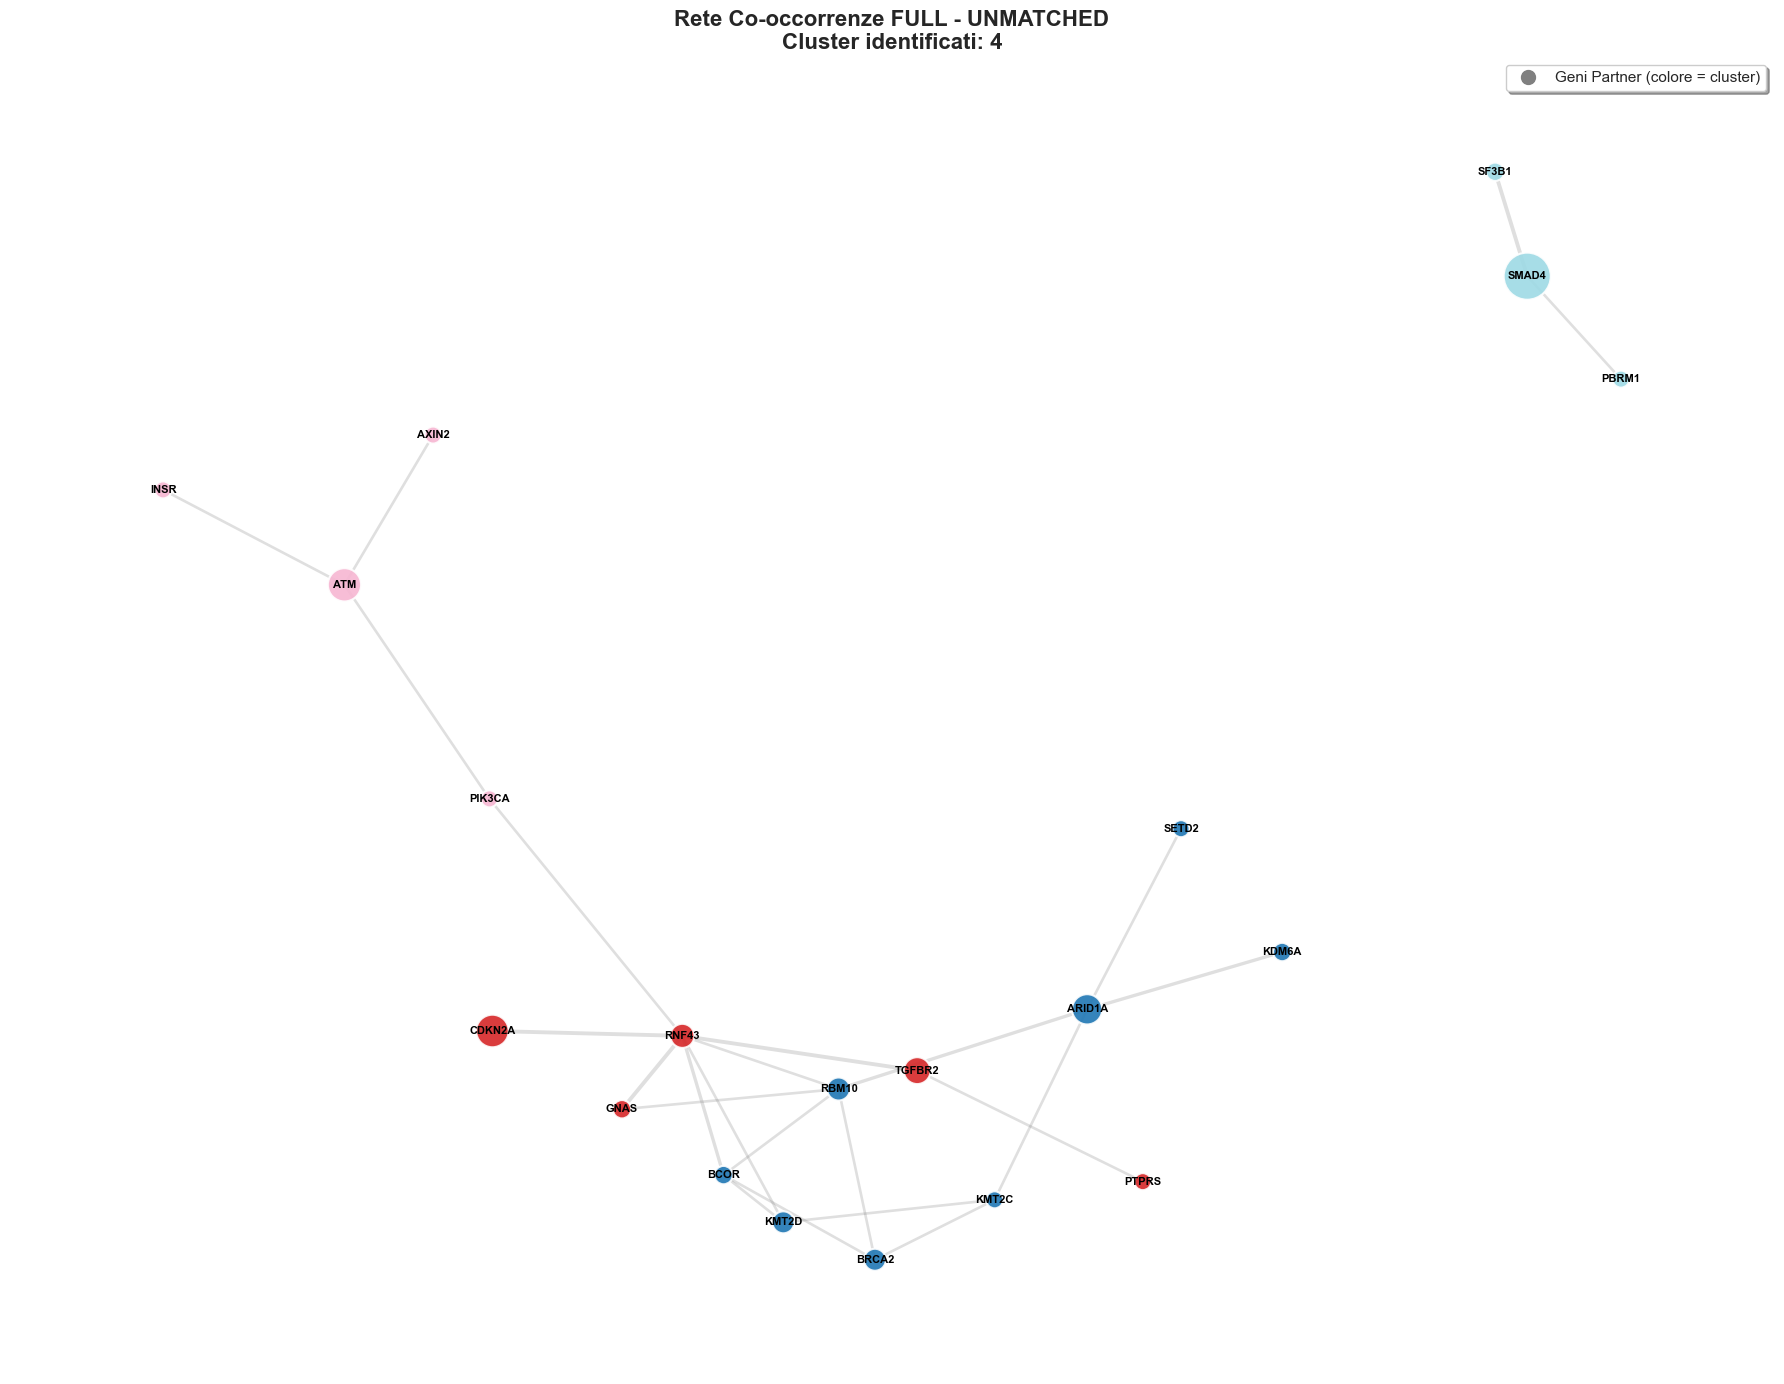

✅ Rete FULL per UNMATCHED salvata. Nodi: 20, Archi: 24
[!] TP53 non presente nella rete (non supera i filtri).

--- 📊 ESTRAZIONE METRICHE: UNMATCHED ---
[-] TP53 non presente, calcolo metriche annullato.


In [7]:
PATH        = "./strat/kras_tp53_pancreas/unmatched"
# PATH        = "./strat/kras_tp53_pancreas/matched"
TARGET_GENE = "TP53"

INPUT_PATH = "./data_filtered/kras_pancreas"
OUTPUT_PATH = "./strat/kras_tp53_pancreas" 
FILE = 'KRAS_F_pancreas.csv'


stratify_cohort(input_dir = INPUT_PATH, output_dir = OUTPUT_PATH, master_filename = FILE, filter_type = 'mutation', gene = TARGET_GENE)

generate_matrices(PATH, TARGET_GENE)
calculate_statistics(PATH, TARGET_GENE, COOCC_PARAMS, ME_PARAMS)
plot_volcanos(PATH, TARGET_GENE, COOCC_PARAMS, ME_PARAMS)
build_all_networks(PATH, TARGET_GENE, COOCC_PARAMS)
calculate_metrics(PATH, TARGET_GENE, COOCC_PARAMS)

In [8]:
# Confronto fra due coorti (opzionale)
compare_networks("./strat/kras_tp53_pancreas/matched", "./strat/kras_tp53_pancreas/unmatched", COOCC_PARAMS, COOCC_PARAMS)


--- 🔀 CONFRONTO RETI: MATCHED vs UNMATCHED ---
Archi totali in MATCHED: 25
Archi totali in UNMATCHED: 24
Archi in comune: 0
Archi persi (presenti solo in MATCHED): 25
Archi guadagnati (presenti solo in UNMATCHED): 24

Top 5 archi guadagnati (per Log2OR):
Gene_A Gene_B    Log2OR    P_Adj
ARID1A  SETD2 10.000000 0.028118
 PBRM1  SMAD4 10.000000 0.103766
 BRCA2  KMT2C  5.865070 0.018172
 KMT2C  KMT2D  5.865070 0.018172
  GNAS  RNF43  5.569856 0.007817



## ALTRO